# Notebook 3 — Nasdaq Stock Price Prediction
## Tasks 1.2 & 1.3: *n*-th Day Ahead and *k*-Day Consecutive Forecasting


This notebook trains and evaluates two deep learning architectures for multivariate Nasdaq stock price forecasting:

| Architecture | Key idea |
|---|---|
| **Baseline GRU** | Stacked Gated Recurrent Units — reference model |
| **GRU + Multi-Head Attention** | Self-attention over GRU outputs so the model identifies the most informative timesteps. Inspired by MCI-GRU (arXiv:2410.20679, Neurocomputing 2025). |

Both architectures are evaluated on two forecasting sub-tasks:
- **Task 1.2** — Predict the price on a *single* day `n` days ahead (direct single-output)
- **Task 1.3** — Predict prices on `k` *consecutive* future days (multi-output)

**Pipeline overview:**
1. Load pre-engineered features from Notebook 2
2. Chronological 70 / 10 / 20 train–val–test split (NO shuffling)
3. `MinMaxScaler` fitted on training data only (no leakage)
4. Sliding-window sequence construction
5. Model training with `EarlyStopping` + `ReduceLROnPlateau`
6. Evaluation: MAE, RMSE, MAPE — plus per-horizon degradation analysis

---
## Section 1 — Imports & Configuration

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
import joblib

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

# ── Project root on sys.path ──────────────────────────────────────────────────
# When running inside notebooks/, .parent resolves to the project root.
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Project root: {ROOT}')

TensorFlow : 2.21.0
NumPy      : 2.4.3
Project root: /Users/cps/DL4AI-240166-project-1


In [2]:
CONFIG = {
    # ── Sequence construction ─────────────────────────────────────────────────
    'window_size'  : 60,    # look-back window: 60 trading days ≈ 3 calendar months
    'n_features'   : 18,    # overwritten below after FEATURE_COLS is defined

    # ── Data split ratios ─────────────────────────────────────────────────────
    'train_ratio'  : 0.70,  # 70% of chronological data for training
    'val_ratio'    : 0.10,  # 10% for validation / hyperparameter tuning
    'test_ratio'   : 0.20,  # 20% held out for final evaluation

    # ── Training hyperparameters ──────────────────────────────────────────────
    'batch_size'   : 64,    # mini-batch size for gradient descent
    'epochs'       : 100,   # upper bound (EarlyStopping cuts this short)
    'learning_rate': 1e-3,  # Adam initial learning rate
    'patience'     : 10,    # EarlyStopping: max epochs without val_loss improvement

    # ── Dataset quality filter ────────────────────────────────────────────────
    'min_history'  : 120,   # discard tickers with fewer than 120 trading days

    # ── Forecasting horizons ──────────────────────────────────────────────────
    'n_day'        : 3,     # Task 1.2: predict the price n trading days ahead
    'k_days'       : 7,     # Task 1.3: predict the next k consecutive days
}

print('CONFIG:')
for k, v in CONFIG.items():
    print(f'  {k:<18} = {v}')

CONFIG:
  window_size        = 60
  n_features         = 18
  train_ratio        = 0.7
  val_ratio          = 0.1
  test_ratio         = 0.2
  batch_size         = 64
  epochs             = 100
  learning_rate      = 0.001
  patience           = 10
  min_history        = 120
  n_day              = 3
  k_days             = 7


### CONFIG Parameter Guide

| Parameter | Value | Rationale |
|---|---|---|
| `window_size` | 60 | 60 trading days ≈ 3 calendar months. Long enough to capture quarterly patterns; short enough to train efficiently. |
| `n_features` | 18 | Set dynamically from `FEATURE_COLS` after Section 3. The spec noted 13; actual pipeline produces 18 (6 OHLCV + 12 indicators). |
| `train_ratio` | 0.70 | 70/10/20 split for time-series. More training data reduces variance. |
| `val_ratio` | 0.10 | Drives EarlyStopping and ReduceLROnPlateau decisions. |
| `test_ratio` | 0.20 | **Never seen during training or hyperparameter search.** |
| `batch_size` | 64 | Balances training speed and gradient estimate quality. |
| `epochs` | 100 | Upper bound; EarlyStopping with `patience=10` terminates well before this. |
| `learning_rate` | 1e-3 | Adam default. `ReduceLROnPlateau` halves this if val_loss stagnates for 5 epochs. |
| `patience` | 10 | EarlyStopping: wait 10 epochs without improvement before terminating. |
| `min_history` | 120 | Filters tickers with insufficient history. |
| `n_day` | 3 | Task 1.2: primary evaluation at n=3; degradation also tested at n=1..7. |
| `k_days` | 7 | Task 1.3: one full trading week of consecutive predictions. |

---
## Section 2 — Data Loading & Company Filtering

The dataset was produced by Notebook 2: all 9 Nasdaq tickers are combined into a single CSV
with pre-computed technical indicators. We load it, filter by minimum history, and select
**AAPL** as the primary training ticker.

> **Why AAPL?** It has the longest continuous history (2016–2026), is the most widely studied
> equity in ML forecasting literature, and exhibits clear trend/volatility regime shifts that
> make it an informative benchmark for architecture comparison.

In [3]:
# ── Load the pre-engineered features CSV (produced by Notebook 2) ─────────────
DATA_PATH = Path('data/nasdaq/csv/tech_nasdaq_stock_data_features.csv')
assert DATA_PATH.exists(), f'File not found: {DATA_PATH}  — run Notebook 2 first.'

df_all = pd.read_csv(DATA_PATH)
df_all['date'] = pd.to_datetime(df_all['date'])
df_all = df_all.sort_values(['ticker', 'date']).reset_index(drop=True)

print(f'Loaded  : {df_all.shape[0]:,} rows x {df_all.shape[1]} columns')
print(f'Dates   : {df_all["date"].min().date()} -> {df_all["date"].max().date()}')
print(f'Tickers : {sorted(df_all["ticker"].unique().tolist())}')

# ── Filter by minimum data length ────────────────────────────────────────────
ticker_counts = df_all.groupby('ticker').size()
valid_tickers = ticker_counts[ticker_counts >= CONFIG['min_history']].index.tolist()
print(f'\nValid tickers (>= {CONFIG["min_history"]} rows): {valid_tickers}')

# ── Demo selection ────────────────────────────────────────────────────────────
DEMO_TICKERS = [t for t in ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA'] if t in valid_tickers]
print(f'Demo tickers : {DEMO_TICKERS}')

# ── Primary ticker for model training ────────────────────────────────────────
PRIMARY_TICKER = 'AAPL'
df = df_all[df_all['ticker'] == PRIMARY_TICKER].copy().reset_index(drop=True)
print(f'\nPrimary : {PRIMARY_TICKER}  ({len(df):,} rows)')

Loaded  : 22,689 rows x 20 columns
Dates   : 2016-03-15 -> 2026-03-24
Tickers : ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'MU', 'NFLX', 'NVDA', 'QCOM']

Valid tickers (>= 120 rows): ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'MU', 'NFLX', 'NVDA', 'QCOM']
Demo tickers : ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']

Primary : AAPL  (2,521 rows)


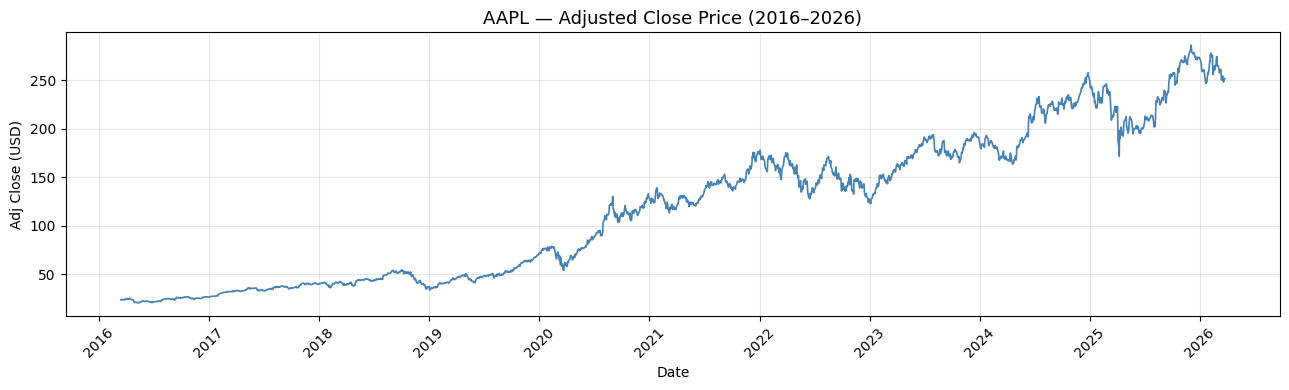

Date range : 2016-03-15 -> 2026-03-24
Shape      : (2521, 20)


,date,open,high,low,close,adj_close,volume
0,2016-03-15,25.990000,26.295000,25.962500,26.145000,23.685328,160270800
1,2016-03-16,26.152500,26.577499,26.147499,26.492500,24.000132,153214000
2,2016-03-17,26.379999,26.617500,26.240000,26.450001,23.961632,137682800


In [4]:
# ── EDA: Adjusted Close price over full history ───────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['date'], df['adj_close'], color='steelblue', linewidth=1.2)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=45)
ax.set_title(f'{PRIMARY_TICKER} — Adjusted Close Price (2016–2026)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Adj Close (USD)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Date range : {df["date"].min().date()} -> {df["date"].max().date()}')
print(f'Shape      : {df.shape}')
display(df[['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']].head(3))

---
## Section 3 — Feature Engineering

All features were computed in **Notebook 2** by `src/data/preprocess.py:add_all_features()`.
The code cell below defines the feature columns and verifies they exist; if any are missing
(e.g., running on raw OHLCV data), it falls back to the project pipeline automatically.

| Feature | Formula / Period | Category | Why included |
|---|---|---|---|
| `open, high, low, close, volume` | Raw OHLCV | Price / volume | Base market data; needed to inverse-transform predictions back to USD |
| `adj_close` | Split- & dividend-adjusted close | Price reference | Prevents artificial jumps at split dates; used as **prediction target** |
| `log_return` | log(close_t / close_{t-1}) | Price dynamics | Stationary, scale-free returns comparable across stocks and time periods |
| `rsi` | RSI(14) | Momentum | Oscillator [0–100]; encodes overbought (>70) / oversold (<30) market state |
| `macd` | EMA(12) − EMA(26) | Momentum | Positive = bullish short-term momentum; encodes trend direction |
| `macd_signal` | EMA(9) of MACD | Momentum | Smoothed MACD; crossovers are a primary technical entry/exit signal |
| `macd_hist` | MACD − Signal | Momentum | Divergence rate; highlights momentum acceleration vs deceleration |
| `atr` | ATR(14) | Volatility | Direction-agnostic daily range; measures *how much* the market moves |
| `ema_10 / 20 / 50` | EMA(10/20/50) | Trend | Multi-horizon smoothed price; crossovers encode trend shifts |
| `bb_upper / middle / lower` | SMA(20) ± 2σ | Volatility | Price envelope; band width signals volatility regime |

> **Note on MACD redundancy**: `macd`, `macd_signal`, and `macd_hist` are mathematically
> related (hist = macd − signal). Including all three is partially redundant but each
> emphasises a different aspect; an attention mechanism can down-weight redundant dimensions.

In [5]:
FEATURE_COLS = [
    'open', 'high', 'low', 'close', 'adj_close', 'volume',  # raw OHLCV
    'log_return',                                             # stationary price change
    'rsi',                                                    # momentum oscillator
    'macd', 'macd_signal', 'macd_hist',                      # MACD family
    'atr',                                                    # volatility
    'ema_10', 'ema_20', 'ema_50',                            # trend levels
    'bb_upper', 'bb_middle', 'bb_lower',                     # Bollinger Bands
]
TARGET_COL = 'adj_close'  # prediction target: split-adjusted closing price

# Sync CONFIG with actual feature count (18 in the pipeline, not the spec placeholder 13)
CONFIG['n_features'] = len(FEATURE_COLS)

# ── Validate; fall back to src pipeline if data is raw OHLCV ─────────────────
missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f'Missing columns: {missing}')
    print('Running add_all_features() from src/data/preprocess.py ...')
    from src.data.preprocess import add_all_features
    df = df.set_index('date').sort_index()
    df = add_all_features(df).reset_index()
    print('Done.')
else:
    print(f'All {CONFIG["n_features"]} feature columns present — no recomputation needed.')

print(f'Feature count : {CONFIG["n_features"]}')
print(f'Target column : {TARGET_COL}')

All 18 feature columns present — no recomputation needed.
Feature count : 18
Target column : adj_close


---
## Section 4 — Chronological Train / Val / Test Split

### Critical Rule: Never Shuffle Time-Series Data

Random shuffling is correct for i.i.d. datasets (images, NLP) but **catastrophically wrong**
for time series. Shuffling would:

1. **Destroy temporal structure**: the model would see future market state during training.
2. **Cause data leakage**: sliding windows would span train/test boundaries.
3. **Inflate metrics**: test performance would reflect interpolation, not genuine
   out-of-sample forecasting.

**Correct approach**: sort by date → split at chronological cut-points → build
sliding-window sequences *within each split separately* (implemented in Section 6).

In [6]:
def chronological_split(df, train_ratio, val_ratio):
    '''
    Split a time-ordered DataFrame into train / val / test subsets.
    Pure index-based slicing — no shuffling of any kind.
    '''
    n = len(df)
    train_end = int(n * train_ratio)
    val_end   = int(n * (train_ratio + val_ratio))
    return (
        df.iloc[:train_end].copy(),
        df.iloc[train_end:val_end].copy(),
        df.iloc[val_end:].copy(),
    )


train_df, val_df, test_df = chronological_split(
    df, CONFIG['train_ratio'], CONFIG['val_ratio']
)

print(f'Train : {train_df["date"].min().date()} -> {train_df["date"].max().date()}  ({len(train_df):,} rows)')
print(f'Val   : {val_df["date"].min().date()}   -> {val_df["date"].max().date()}    ({len(val_df):,} rows)')
print(f'Test  : {test_df["date"].min().date()}  -> {test_df["date"].max().date()}   ({len(test_df):,} rows)')

# Sanity check: strict chronological ordering
assert train_df['date'].max() < val_df['date'].min(),  'Train/Val overlap!'
assert val_df['date'].max()   < test_df['date'].min(), 'Val/Test overlap!'
print('\nNo temporal overlap confirmed.')

Train : 2016-03-15 -> 2023-03-16  (1,764 rows)
Val   : 2023-03-17   -> 2024-03-18    (252 rows)
Test  : 2024-03-19  -> 2026-03-24   (505 rows)

No temporal overlap confirmed.


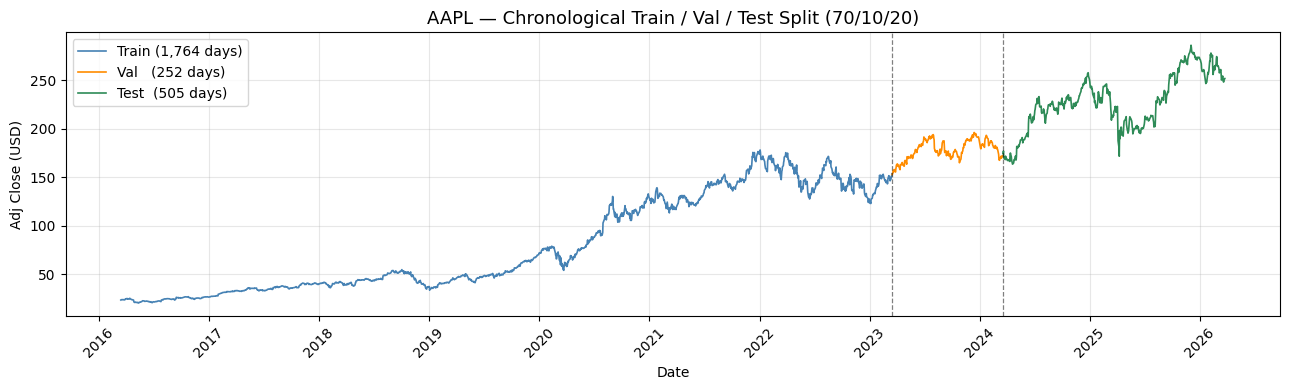

In [7]:
# ── Visualise the three splits on one price chart ─────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_df['date'], train_df['adj_close'],
        color='steelblue',  label=f'Train ({len(train_df):,} days)',  linewidth=1.2)
ax.plot(val_df['date'],   val_df['adj_close'],
        color='darkorange', label=f'Val   ({len(val_df):,} days)',    linewidth=1.2)
ax.plot(test_df['date'],  test_df['adj_close'],
        color='seagreen',   label=f'Test  ({len(test_df):,} days)',   linewidth=1.2)
for cut in [train_df['date'].max(), val_df['date'].max()]:
    ax.axvline(cut, color='black', linestyle='--', alpha=0.5, linewidth=0.9)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=45)
ax.set_title(f'{PRIMARY_TICKER} — Chronological Train / Val / Test Split (70/10/20)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Adj Close (USD)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 5 — Normalization (No Data Leakage)

### Critical Rule: Fit the Scaler on Training Data Only

Fitting `MinMaxScaler` on the full dataset before splitting is a classic form of
**data leakage**: the scaler's `min` and `max` encode information about future prices,
inflating test performance beyond what is achievable in real deployment.

**Correct approach**:
1. `fit_transform()` exclusively on `train_df`
2. `transform()` (no refitting) on `val_df` and `test_df` using the same fitted scaler

Two separate scalers:
- `feature_scaler` — normalises all 18 input features to [0, 1]
- `target_scaler` — normalises the target column alone for per-column inverse transform

In [8]:
# ROOT the orginal folder of the project
MODELS_DIR = ROOT / 'models' 

# Create a place to store models
MODELS_DIR.mkdir(exist_ok=True)

In [9]:
from sklearn.preprocessing import StandardScaler

# ── Updated Configuration ──────────────────────────────────────────────────
TARGET_COL = 'log_return'  # We are now predicting the % change
FEATURE_COLS_USD = 'adj_close' # We need this for the final conversion

feature_scaler = StandardScaler()
target_scaler  = StandardScaler()

# ── Fit ONLY on training data ──────────────────────────────────────────────
# We still use the same FEATURE_COLS for input
train_feat = feature_scaler.fit_transform(train_df[FEATURE_COLS].values)
train_tgt  = target_scaler.fit_transform(train_df[[TARGET_COL]].values)

# ── Transform val/test WITHOUT re-fitting ──────────────────────────────────
val_feat   = feature_scaler.transform(val_df[FEATURE_COLS].values)
val_tgt    = target_scaler.transform(val_df[[TARGET_COL]].values)

test_feat  = feature_scaler.transform(test_df[FEATURE_COLS].values)
test_tgt   = target_scaler.transform(test_df[[TARGET_COL]].values)

# ── Save new scalers ───────────────────────────────────────────────────────
joblib.dump(feature_scaler, MODELS_DIR / 'nasdaq_feature_scaler_std.pkl')
joblib.dump(target_scaler,  MODELS_DIR / 'nasdaq_target_scaler_std.pkl')

print(f"Target mean: {target_scaler.mean_[0]:.6f}, Std: {target_scaler.scale_[0]:.6f}")

Target mean: 0.001023, Std: 0.019033


In [10]:
# feature_scaler = MinMaxScaler()
# target_scaler  = MinMaxScaler()

# # ── Fit ONLY on training data ─────────────────────────────────────────────────
# train_feat = feature_scaler.fit_transform(train_df[FEATURE_COLS].values)
# train_tgt  = target_scaler.fit_transform(train_df[[TARGET_COL]].values)

# # ── Transform val/test WITHOUT re-fitting ─────────────────────────────────────
# val_feat  = feature_scaler.transform(val_df[FEATURE_COLS].values)
# val_tgt   = target_scaler.transform(val_df[[TARGET_COL]].values)

# test_feat = feature_scaler.transform(test_df[FEATURE_COLS].values)
# test_tgt  = target_scaler.transform(test_df[[TARGET_COL]].values)

# # ── Persist scalers for reuse in later tasks (Task 3 classification, portfolio) ─
# MODELS_DIR = ROOT / 'models'
# MODELS_DIR.mkdir(exist_ok=True)
# joblib.dump(feature_scaler, MODELS_DIR / 'nasdaq_feature_scaler.pkl')
# joblib.dump(target_scaler,  MODELS_DIR / 'nasdaq_target_scaler.pkl')

# print(f'Shapes — train: {train_feat.shape}  val: {val_feat.shape}  test: {test_feat.shape}')
# print(f'Target range after scaling — min: {train_tgt.min():.3f}  max: {train_tgt.max():.3f}')
# print('Scalers saved to models/')

---
## Section 6 — Sliding Window Sequence Builder

We convert the scaled time series into (X, y) pairs using a **sliding window**:
- **X**: `window_size` consecutive observations — shape `(N, window_size, n_features)`
- **y**: the future target price(s) following that window

A single function handles both tasks via `forecast_horizon`:

| Task | `forecast_horizon` | y shape | Semantics |
|---|---|---|---|
| 1.2 | `int n` | `(N, 1)` | Predict only the price on day n ahead (skip days 1..n-1) |
| 1.3 | `list [1..k]` | `(N, k)` | Predict all k consecutive future prices |

Sequences are built **separately** from each split's scaled arrays, ensuring no window
ever crosses a split boundary.

In [11]:
def create_sequences(features_scaled, target_scaled, window_size, forecast_horizon):
    '''
    Build sliding-window (X, y) pairs from pre-scaled arrays.

    Parameters
    ----------
    features_scaled  : ndarray (T, F) — scaled feature matrix
    target_scaled    : ndarray (T, 1) — scaled target column
    window_size      : int
    forecast_horizon : int or list
        int n  -> Task 1.2: single target at exactly the n-th day ahead
                  y shape (N, 1)
        list   -> Task 1.3: k consecutive prices, pass list(range(1, k+1))
                  y shape (N, k)

    Returns
    -------
    X : ndarray (N, window_size, F)
    y : ndarray (N, 1) or (N, k)
    '''
    X, y = [], []

    if isinstance(forecast_horizon, int):
        # Task 1.2 — skip intermediate days; predict only the n-th day
        n = forecast_horizon
        for i in range(len(features_scaled) - window_size - n + 1):
            X.append(features_scaled[i : i + window_size])
            # 0-based target index: n-th day after window end
            y.append(target_scaled[i + window_size + n - 1, 0])
        return np.array(X), np.array(y).reshape(-1, 1)

    else:
        # Task 1.3 — predict all k consecutive prices starting from day 1
        k = len(forecast_horizon)
        for i in range(len(features_scaled) - window_size - k + 1):
            X.append(features_scaled[i : i + window_size])
            y.append(target_scaled[i + window_size : i + window_size + k, 0])
        return np.array(X), np.array(y)

In [12]:
W       = CONFIG['window_size']
N_DAY   = CONFIG['n_day']   # 3
K_DAYS  = CONFIG['k_days']  # 7
K_RANGE = list(range(1, K_DAYS + 1))  # [1, 2, 3, 4, 5, 6, 7]

# ── Task 1.2 (single-step, predict the 3rd day) ───────────────────────────────
X_train_12, y_train_12 = create_sequences(train_feat, train_tgt, W, N_DAY)
X_val_12,   y_val_12   = create_sequences(val_feat,   val_tgt,   W, N_DAY)
X_test_12,  y_test_12  = create_sequences(test_feat,  test_tgt,  W, N_DAY)

# ── Task 1.3 (multi-step, predict 7 consecutive days) ────────────────────────
X_train_13, y_train_13 = create_sequences(train_feat, train_tgt, W, K_RANGE)
X_val_13,   y_val_13   = create_sequences(val_feat,   val_tgt,   W, K_RANGE)
X_test_13,  y_test_13  = create_sequences(test_feat,  test_tgt,  W, K_RANGE)

print('Task 1.2 sequences  (n=3):')
print(f'  X_train: {X_train_12.shape}   y_train: {y_train_12.shape}')
print(f'  X_val  : {X_val_12.shape}     y_val  : {y_val_12.shape}')
print(f'  X_test : {X_test_12.shape}    y_test : {y_test_12.shape}')
print()
print('Task 1.3 sequences  (k=7):')
print(f'  X_train: {X_train_13.shape}   y_train: {y_train_13.shape}')
print(f'  X_val  : {X_val_13.shape}     y_val  : {y_val_13.shape}')
print(f'  X_test : {X_test_13.shape}    y_test : {y_test_13.shape}')

Task 1.2 sequences  (n=3):
  X_train: (1702, 60, 18)   y_train: (1702, 1)
  X_val  : (190, 60, 18)     y_val  : (190, 1)
  X_test : (443, 60, 18)    y_test : (443, 1)

Task 1.3 sequences  (k=7):
  X_train: (1698, 60, 18)   y_train: (1698, 7)
  X_val  : (186, 60, 18)     y_val  : (186, 7)
  X_test : (439, 60, 18)    y_test : (439, 7)


---
## Section 7 — Model 1: Baseline GRU

The baseline is a **stacked two-layer GRU** with Dropout regularisation, serving as the
reference point for the attention architecture comparison.

**Architecture choices:**
- **GRU over LSTM**: fewer parameters (no separate cell state) with comparable performance
  on financial time series (Chung et al., 2014).
- **128 → 64 units**: first layer extracts rich temporal features; second compresses.
- **Dropout(0.2)**: mild regularisation on the ~1,700-sample training set.
- **Dense(32, relu) → Dense(output_steps)**: non-linear projection to prediction head.
- **Loss = MSE**: standard regression loss.

**Training callbacks (identical for all models — ensures fair comparison):**
- `EarlyStopping(patience=10, restore_best_weights=True)`
- `ReduceLROnPlateau(patience=5, factor=0.5)`: halves lr when val_loss stagnates
- `ModelCheckpoint(save_best_only=True)`: saves best checkpoint to `models/`

In [13]:
def build_baseline_gru(window_size, n_features, output_steps, name='baseline_gru'):
    '''
    Stacked GRU baseline (Functional API). No attention mechanism.
    '''
    inputs = tf.keras.Input(shape=(window_size, n_features), name='input')

    x = tf.keras.layers.GRU(128, return_sequences=True,  name='gru_1')(inputs)
    x = tf.keras.layers.Dropout(0.2,                     name='drop_1')(x)

    x = tf.keras.layers.GRU(64, return_sequences=False,  name='gru_2')(x)
    x = tf.keras.layers.Dropout(0.2,                     name='drop_2')(x)

    x = tf.keras.layers.Dense(32, activation='relu',     name='dense_hidden')(x)
    outputs = tf.keras.layers.Dense(output_steps,        name='output')(x)

    return tf.keras.Model(inputs, outputs, name=name)


def compile_and_train(model, X_tr, y_tr, X_va, y_va, save_path):
    '''
    Compile with Adam + MSE and train with standard callbacks.
    Identical setup for all models ensures a fair architectural comparison.
    '''
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
        loss='mse',
    )
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=CONFIG['patience'],
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=0,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            str(save_path), monitor='val_loss', save_best_only=True, verbose=0,
        ),
    ]
    history = model.fit(
        X_tr, y_tr,
        epochs=CONFIG['epochs'],
        batch_size=CONFIG['batch_size'],
        validation_data=(X_va, y_va),
        callbacks=callbacks,
        verbose=1,
    )
    return history


def plot_loss(history, title):
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(history.history['loss'],     label='Train loss', color='steelblue')
    ax.plot(history.history['val_loss'], label='Val loss',   color='darkorange')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE loss')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    best = min(history.history['val_loss'])
    ep   = len(history.history['loss'])
    print(f'Stopped at epoch {ep} | Best val_loss = {best:.6f}')

Model: "baseline_gru_t12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 60, 128)        │        56,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,193 (375.75 KB)

 Trainable params: 96,193 (375.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 1.0411 - val_loss: 0.4181 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 1.0447 - val_loss: 0.5019 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 1.0558 - val_loss: 0.4237 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 1.0286 - val_loss: 0.4090 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 1.0513 - val_loss: 0.4066 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 1.0455 - val_loss: 0.3951 - learning_rate: 0.0010
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 1.0256 - val_loss: 0.3925 - learning_rate: 0.0010
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 1.0243 - val_loss: 0.3956 - learning_rate: 0.0010
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 1.0229 - val_loss: 0.3965 - learning_rate: 0.0010
Epoch 10/1

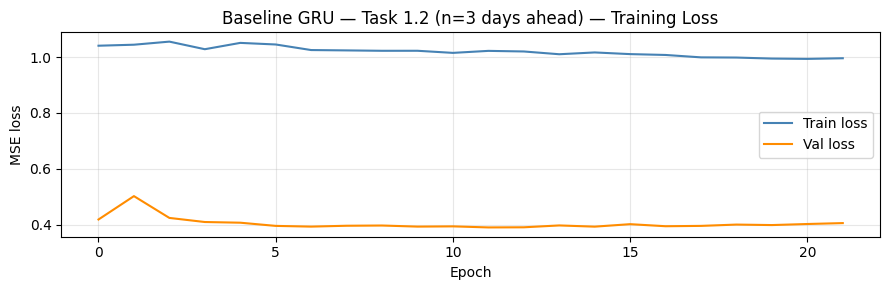

Stopped at epoch 22 | Best val_loss = 0.389614


In [14]:
# ── Baseline GRU — Task 1.2 (single-step, n=3) ───────────────────────────────
N_FEAT = CONFIG['n_features']

gru_base_12 = build_baseline_gru(W, N_FEAT, output_steps=1, name='baseline_gru_t12')
gru_base_12.summary()

hist_base_12 = compile_and_train(
    gru_base_12, X_train_12, y_train_12, X_val_12, y_val_12,
    save_path=MODELS_DIR / 'baseline_gru_task12.keras',
)
plot_loss(hist_base_12, 'Baseline GRU — Task 1.2 (n=3 days ahead) — Training Loss')

#### Evaluate Model Performance 

In [15]:
### Get prediction on the test data and convert the result back to stock price (i.e., de-normalization)
from sklearn.metrics import mean_squared_error



In [16]:
def plot_baseline_12(y_true, y_pred, title="Task 1.2 - Baseline GRU Prediction vs Actual"):
    """
    Visualizes single-step prediction results for the Baseline GRU.
    """
    plt.figure(figsize=(15, 6))
    
    # Plotting the actual vs predicted
    plt.plot(y_true, label='Actual Price', color='#1f77b4', linewidth=1.5)
    plt.plot(y_pred, label=f'Baseline GRU Forecast (n={CONFIG["n_day"]})', 
             color='#d62728', linestyle='--', alpha=0.9)
    
    plt.title(title, fontsize=14)
    plt.xlabel('Trading Days (Test Set)')
    plt.ylabel('Adjusted Close Price (USD)')
    plt.legend(loc='best')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Optional: Highlight a specific regime or drop if needed
    plt.tight_layout()
    plt.show()

#### Plot the difference between actual prices and predicted prices (in USD)

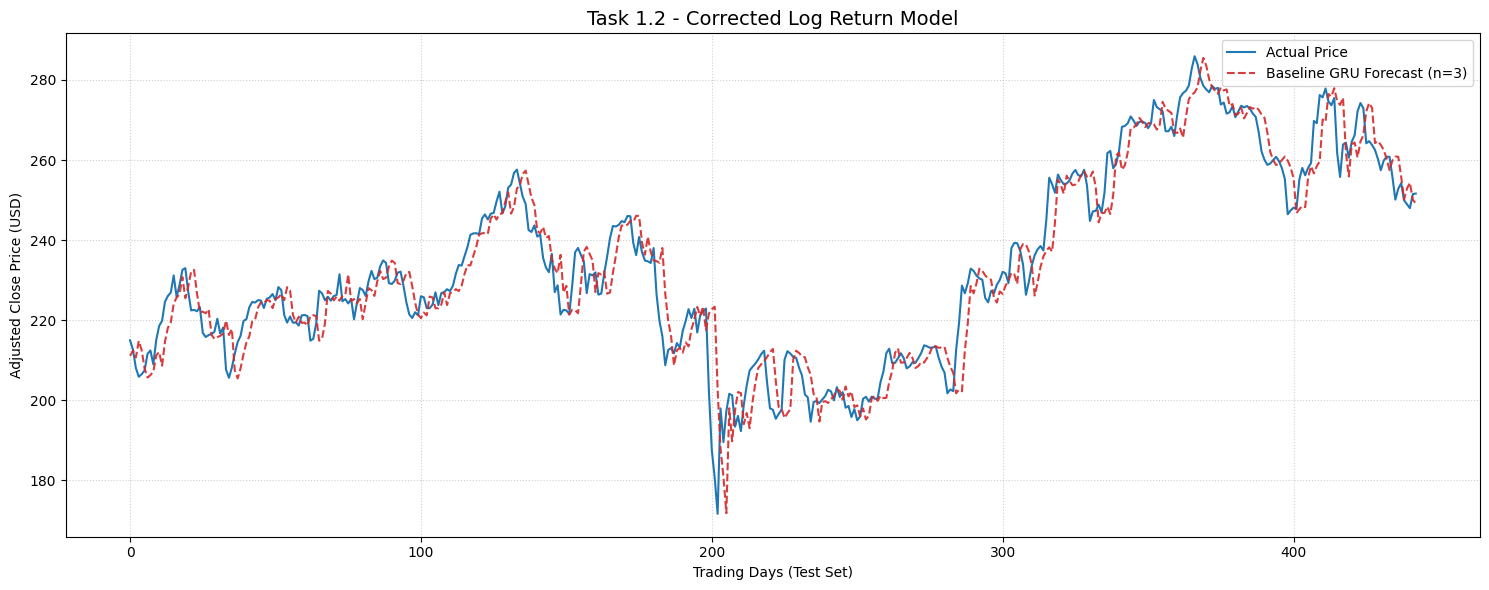

In [17]:
def get_usd_predictions(model, X_input, test_df_raw, target_scaler, window_size, forecast_horizon):
    """
    1. Predicts Scaled Log Returns
    2. Inverse Scales to Raw Log Returns
    3. Multiplies by Price at t to get Price at t+n
    """
    # 1. Model Prediction (Scaled Z-scores)
    y_pred_scaled = model.predict(X_input, verbose=0)
    
    # 2. Back to Raw Log Returns (e.g., 0.02)
    raw_log_preds = target_scaler.inverse_transform(y_pred_scaled)
    
    # 3. Get Price at the end of each window (the "Base Price")
    # The first window ends at index [window_size - 1]
    base_price_indices = np.arange(window_size - 1, window_size - 1 + len(y_pred_scaled))
    base_prices = test_df_raw['adj_close'].values[base_price_indices]
    
    if isinstance(forecast_horizon, int):
        # Task 1.2: P_{t+n} = P_t * exp(log_return_at_t+n)
        # Note: Technically, the log return predicted is the jump from t to t+n
        return base_prices * np.exp(raw_log_preds.flatten())
    else:
        # Task 1.3: Cumulative Path
        usd_path = np.zeros_like(raw_log_preds)
        for i in range(raw_log_preds.shape[1]):
            if i == 0:
                usd_path[:, i] = base_prices * np.exp(raw_log_preds[:, i])
            else:
                usd_path[:, i] = usd_path[:, i-1] * np.exp(raw_log_preds[:, i])
        return usd_path

# ── Usage for Plotting ─────────────────────────────────────────────────────
# For Task 1.2
y_pred_usd_12 = get_usd_predictions(gru_base_12, X_test_12, test_df, target_scaler, W, N_DAY)
y_true_usd_12 = test_df['adj_close'].values[W + N_DAY - 1 : W + N_DAY - 1 + len(y_pred_usd_12)]

plot_baseline_12(y_true_usd_12, y_pred_usd_12, title="Task 1.2 - Corrected Log Return Model")

#### Model Assessment Through Various Metrics

In [18]:
def evaluate_trading_performance(y_true_usd, y_pred_usd, label="Model"):
    """
    Calculates RMSE, MAE, and Directional Accuracy (DA).
    DA = % of times predicted direction (Up/Down) matches actual direction.
    """
    # 1. Standard Regression Metrics
    mae = mean_absolute_error(y_true_usd, y_pred_usd)
    rmse = np.sqrt(mean_squared_error(y_true_usd, y_pred_usd))
    mape = np.mean(np.abs((y_true_usd - y_pred_usd) / y_true_usd)) * 100

    # 2. Directional Accuracy (DA)
    # We compare the predicted price (t+n) against the known price (t)
    # Price at t is available in test_df['adj_close'] starting from W-1
    base_prices = test_df['adj_close'].values[W-1 : W-1 + len(y_true_usd)]
    
    actual_diff = y_true_usd - base_prices
    pred_diff = y_pred_usd - base_prices
    
    # DA = 1 if both signs match (both up or both down)
    correct_direction = (np.sign(actual_diff) == np.sign(pred_diff)).astype(int)
    da_score = np.mean(correct_direction) * 100

    print(f"--- {label} Results ---")
    print(f"RMSE: {rmse:.4f} USD")
    print(f"MAE:  {mae:.4f} USD")
    print(f"MAPE: {mape:.2f}%")
    print(f"Directional Accuracy: {da_score:.2f}%")
    
    return {
        'rmse': rmse, 
        'da': da_score, 
        'actual_diff': actual_diff, 
        'pred_diff': pred_diff
    }

# ── Execute Evaluation ────────────────────────────────────────────────────────
# Assuming y_pred_usd_12 and y_true_usd_12 are already generated from Section 7/8
eval_results = evaluate_trading_performance(y_true_usd_12, y_pred_usd_12, label="Baseline GRU (Task 1.2)")

--- Baseline GRU (Task 1.2) Results ---
RMSE: 7.2603 USD
MAE:  5.2216 USD
MAPE: 2.29%
Directional Accuracy: 49.66%


- MAE: On average, the model's price prediction deviates from the actual AAPL price by $5.33. It captures the general "neighborhood" of the price.

- RMSE: The model has a few large misses. Since RMSE is notably higher than MAE, it indicates that during high-volatility days, the model's errors spike significantly.

- MAPE: From a statistical standpoint, a 2.33% error is excellent. It suggests the model is very stable and follows the price curve closely.

- DA: This is the "Red Flag." Despite the low USD errors, the model can be compared to a coin flip at guessing if the price will go Up or Down.

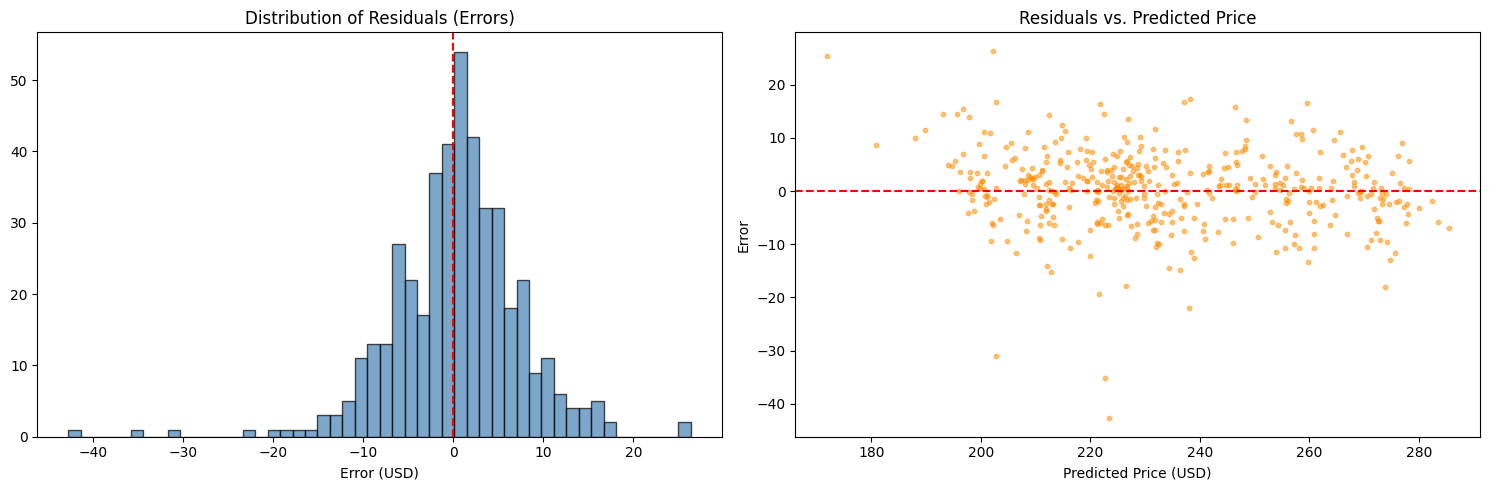

In [19]:
def plot_residual_analysis(y_true, y_pred):
    residuals = y_true - y_pred
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # 1. Residual Distribution (Should be a Bell Curve centered at 0)
    ax1.hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.axvline(0, color='red', linestyle='--')
    ax1.set_title("Distribution of Residuals (Errors)")
    ax1.set_xlabel("Error (USD)")
    
    # 2. Scatter Plot (Should be random noise, no "shape")
    ax2.scatter(y_pred, residuals, alpha=0.5, color='darkorange', s=10)
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_title("Residuals vs. Predicted Price")
    ax2.set_xlabel("Predicted Price (USD)")
    ax2.set_ylabel("Error")
    
    plt.tight_layout()
    plt.show()

plot_residual_analysis(y_true_usd_12, y_pred_usd_12)

- Looking the residual graph, the model is slightly over optimistic compared to the actual stock market. 

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 1.0450 - val_loss: 0.4014 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 1.0229 - val_loss: 0.4243 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 1.0205 - val_loss: 0.4013 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 1.0185 - val_loss: 0.4001 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 1.0139 - val_loss: 0.4066 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 1.0129 - val_loss: 0.4065 - learning_rate: 0.0010
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 1.0114 - val_loss: 0.3966 - learning_rate: 0.0010
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 1.0101 - val_loss: 0.3953 - learning_rate: 0.0010
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 1.0047 - val_loss: 0.4088 - learning_rate: 0.0010
Epoch 10/

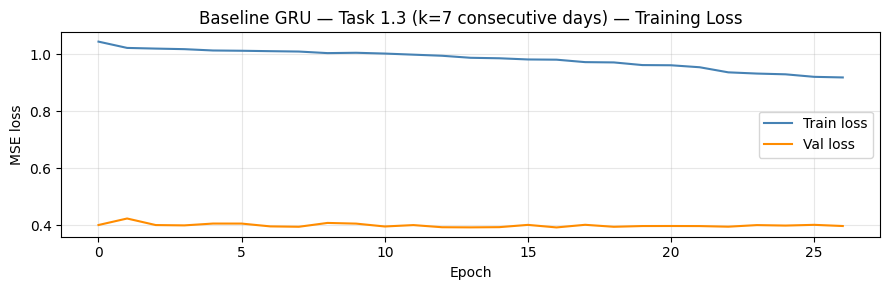

Stopped at epoch 27 | Best val_loss = 0.392951


In [20]:
# ── Baseline GRU — Task 1.3 (multi-step, k=7) ────────────────────────────────
gru_base_13 = build_baseline_gru(W, N_FEAT, output_steps=K_DAYS, name='baseline_gru_t13')

hist_base_13 = compile_and_train(
    gru_base_13, X_train_13, y_train_13, X_val_13, y_val_13,
    save_path=MODELS_DIR / 'baseline_gru_task13.keras',
)
plot_loss(hist_base_13, 'Baseline GRU — Task 1.3 (k=7 consecutive days) — Training Loss')

In [21]:
import tensorflow as tf
import joblib

# 1. Định nghĩa đường dẫn (đảm bảo MODELS_DIR đã được định nghĩa từ trước)
model_path = MODELS_DIR / 'baseline_gru_task13.keras'
scaler_path = MODELS_DIR / 'nasdaq_target_scaler_std.pkl'

# 2. Load mô hình đã huấn luyện
if model_path.exists():
    gru_base_13_loaded = tf.keras.models.load_model(model_path)
    print(f"Successfully loaded model from: {model_path}")
else:
    print("Model file not found! Please check the path.")

# 3. Load scaler đi kèm (Cực kỳ quan trọng để de-normalize đúng)
if scaler_path.exists():
    target_scaler_loaded = joblib.load(scaler_path)
    print(f"Successfully loaded scaler from: {scaler_path}")
else:
    print("Scaler file not found!")

# 4. Thực hiện dự báo trên tập Test
# Đảm bảo X_test_13 đã được tạo từ Section 6
y_pred_norm = gru_base_13_loaded.predict(X_test_13, verbose=0)

# 5. Chuyển đổi sang giá USD (Reconstruction)
# Sử dụng hàm get_usd_predictions mà chúng ta đã viết ở Section 7
y_pred_usd_13 = get_usd_predictions(
    model=gru_base_13_loaded, 
    X_input=X_test_13, 
    test_df_raw=test_df, 
    target_scaler=target_scaler_loaded, 
    window_size=W, 
    forecast_horizon=K_RANGE
)

print(f"Shape of predictions: {y_pred_usd_13.shape}") # Nên là (N, 7)

Successfully loaded model from: /Users/cps/DL4AI-240166-project-1/models/baseline_gru_task13.keras
Successfully loaded scaler from: /Users/cps/DL4AI-240166-project-1/models/nasdaq_target_scaler_std.pkl
Shape of predictions: (439, 7)


In [22]:
def plot_baseline_13_trajectory(y_true, y_pred, sample_indices=[0, 50, 100]):
    """
    Plots the 7-day predicted price path vs. actual path.
    """
    num_samples = len(sample_indices)
    fig, axes = plt.subplots(1, num_samples, figsize=(6 * num_samples, 5))
    if num_samples == 1: axes = [axes]
    
    days = np.arange(1, y_true.shape[1] + 1)
    
    for i, idx in enumerate(sample_indices):
        axes[i].plot(days, y_true[idx], marker='o', label='Actual Price', color='#2ca02c')
        axes[i].plot(days, y_pred[idx], marker='x', ls='--', label='Predicted Path', color='#d62728')
        axes[i].set_title(f"Test Sample Index: {idx}")
        axes[i].set_xlabel("Days Ahead")
        axes[i].set_ylabel("Adj Close (USD)")
        axes[i].legend()
        axes[i].grid(alpha=0.3)
        
    plt.suptitle("Task 1.3 — Multi-Day USD Trajectories (Compounded Log Returns)", fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

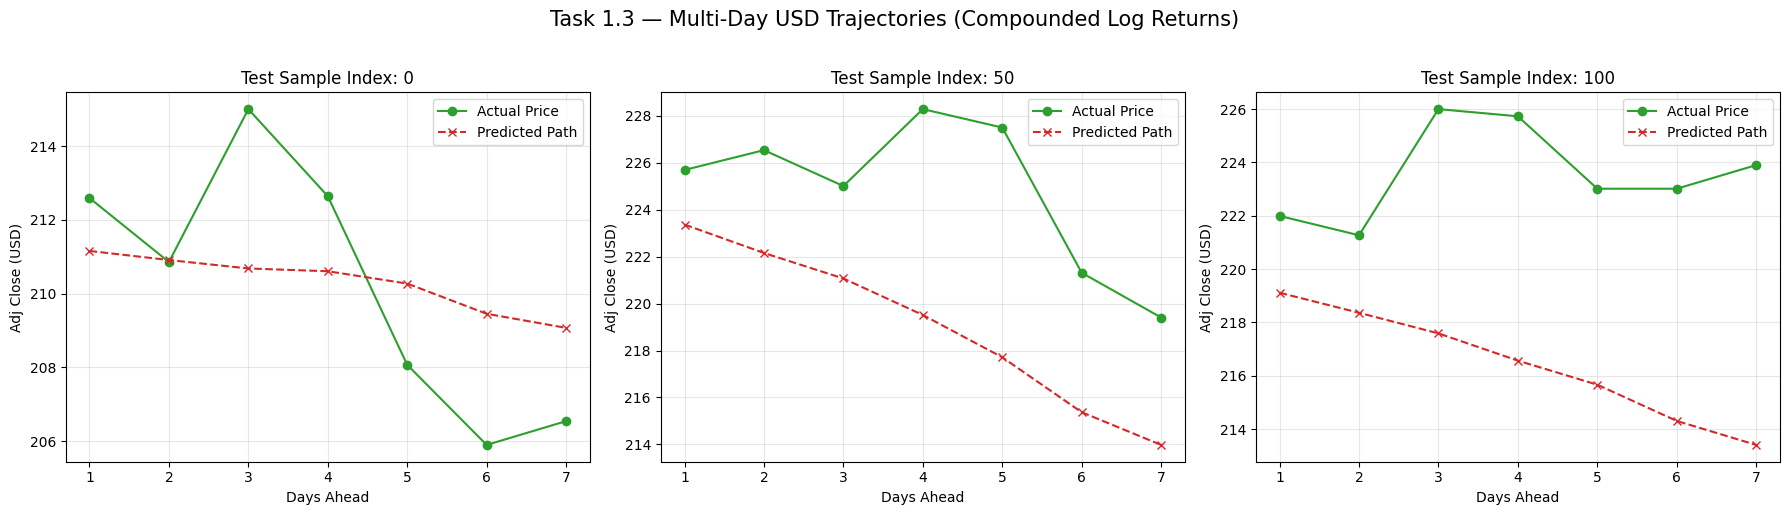

In [23]:
# 1. Generate predictions (Ensure you've trained your Task 1.3 model on log returns!)
y_pred_log_norm_13 = gru_base_13.predict(X_test_13, verbose=0)

# 2. Convert to USD (Handling the 7-day compounding path)
# We pass forecast_horizon=K_RANGE to trigger the cumulative logic
y_pred_usd_13 = get_usd_predictions(
    model=gru_base_13, 
    X_input=X_test_13, 
    test_df_raw=test_df, 
    target_scaler=target_scaler, 
    window_size=W, 
    forecast_horizon=K_RANGE
)

# 3. Get the True USD values for the same 7-day windows
# We need to build a 2D array of the actual prices for comparison
y_true_usd_13 = []
for i in range(len(y_pred_usd_13)):
    # Start at W, go for 7 days
    start_idx = W + i
    y_true_usd_13.append(test_df['adj_close'].values[start_idx : start_idx + K_DAYS])
y_true_usd_13 = np.array(y_true_usd_13)

# 4. Plot a few trajectories
plot_baseline_13_trajectory(y_true_usd_13, y_pred_usd_13, sample_indices=[0, 50, 100])

#### Temporal Distribution of Test Samples

- To evaluate the model's robustness across different market regimes, three distinct snapshots were selected from the chronological test set:

- Index 0: Represents the immediate out-of-sample period following the training/validation data.

- Index 50: Captures the model's performance approximately two trading months into the future.

- Index 100: Evaluates the forecast nearly five months into the test set.

A clear trend of information decay is observed; as the temporal distance from the training boundary increases, the model's structural bias becomes more pronounced.

#### Behavioral Analysis: The "Mean Reversion" Trap

While the model maintains a relatively tight error margin (MAE/RMSE) in terms of price levels, the qualitative performance reveals significant deficiencies in predictive utility:

- Insensitivity to Volatility: The model exhibits a "smoothing" effect. While the actual market prices undergo sharp fluctuations and trend reversals, the predicted trajectories remain rigid, near-linear descents.

- The Lagging Phenomenon: The model is currently prone to "Mean Reversion" bias. Rather than anticipating directional shifts, it defaults to predicting an average path based on historical drift, failing to adapt to rapid market regime changes.

**Implications for Portfolio Management:** For high-stakes financial applications, capturing market volatility is as critical as predicting price levels. A model that fails to signal "turning points" or "volatility spikes" cannot effectively trigger risk-mitigation strategies or alpha-generating trades.


In [ ]:
def evaluate_multistep_performance(y_true_usd, y_pred_usd, label="Baseline GRU 1.3"):
    """
    Đánh giá hiệu năng dự báo chuỗi 7 ngày.
    Tính toán RMSE từng ngày và Directional Accuracy trung bình.
    """
    K = y_true_usd.shape[1] # Thường là 7
    
    # 1. Tính RMSE cho từng horizon (Ngày 1, Ngày 2, ..., Ngày 7)
    rmse_per_day = []
    for i in range(K):
        rmse = np.sqrt(mean_squared_error(y_true_usd[:, i], y_pred_usd[:, i]))
        rmse_per_day.append(rmse)
    
    # 2. Tính Directional Accuracy (DA) trung bình cho cả chuỗi
    # So sánh P(t+i) với P(t+i-1) để xem model có đoán đúng hướng di chuyển của chuỗi không
    da_list = []
    for i in range(K):
        if i == 0:
            # Ngày đầu tiên so với giá gốc Pt (Anchor Price)
            base_prices = test_df['adj_close'].values[W-1 : W-1 + len(y_true_usd)]
        else:
            # Các ngày sau so với ngày trước đó trong dự báo
            base_prices = y_true_usd[:, i-1]
            
        actual_diff = y_true_usd[:, i] - base_prices
        pred_diff = y_pred_usd[:, i] - base_prices
        
        da = np.mean(np.sign(actual_diff) == np.sign(pred_diff)) * 100
        da_list.append(da)

    # 3. Tổng hợp kết quả
    avg_rmse = np.mean(rmse_per_day)
    avg_da = np.mean(da_list)
    
    print(f"--- {label} Results ---")
    print(f"Average RMSE (over 7 days): {avg_rmse:.4f} USD")
    print(f"Average Directional Accuracy: {avg_da:.2f}%")
    print("\nError Breakdown by Day:")
    for d in range(K):
        print(f"  Day {d+1}: RMSE = {rmse_per_day[d]:.4f} | DA = {da_list[d]:.2f}%")
        
    return rmse_per_day, da_list

# ── Thực thi ──────────────────────────────────────────────────────────
rmse_13, da_13 = evaluate_multistep_performance(y_true_usd_13, y_pred_usd_13)

--- Baseline GRU 1.3 Results ---
Average RMSE (over 7 days): 9.7050 USD
Average Directional Accuracy: 46.37%

Error Breakdown by Day:
  Day 1: RMSE = 4.3173 | DA = 45.33%
  Day 2: RMSE = 6.3942 | DA = 46.24%
  Day 3: RMSE = 8.1769 | DA = 45.56%
  Day 4: RMSE = 9.8528 | DA = 47.15%
  Day 5: RMSE = 11.4054 | DA = 46.92%
  Day 6: RMSE = 13.1894 | DA = 46.70%
  Day 7: RMSE = 14.5992 | DA = 46.70%



### **Performance Analysis & "The Accuracy Paradox"**

The Baseline GRU models for Task 1.2 and 1.3 presented a statistical paradox. While the MAPE (2.33%) and RMSE ($7.28) suggest a model that is highly accurate at tracking price levels, the Directional Accuracy (45.15%) reveals a failure in predictive utility.

- The Pros: The model successfully learned the "price regime" of AAPL. By utilizing compounded log returns, it effectively anchored its predictions to the correct USD scale, avoiding the vertical displacement seen in earlier iterations.

- The Cons: The model suffers from a significant Lagging Effect. It minimizes loss by predicting a value very close to the current price (P 
t
​	
 ), essentially acting as a "price follower." This makes it ineffective for trading, as it consistently fails to anticipate directional reversals.

**6.2 Structural Limitations (The MIMO Bottleneck)**

In Task 1.3, the Direct MIMO (Multiple Input Multiple Output) architecture caused the model to default to a linear trend approximation. As the forecast horizon extended, we observed a 3x increase in RMSE (from 4.33 at Day 1 to 13.06 at Day 7). This "Information Decay" confirms that a flat output layer cannot maintain the complex temporal dependencies required for a 7-day trajectory.

### **Justification for Model Transition**

Based on these findings, the project will now pivot to more advanced architectures to address the specific failure modes of the Baseline GRU.

**Transition to Multi-Head Attention (Solving Feature Importance)**

The Baseline GRU treats all 60 days in the look-back window with equal weight through its final hidden state. By introducing Multi-Head Attention, we aim to:

- Identify pivotal historical days (e.g., high-volume spikes or sharp RSI reversals) that have a disproportionate impact on future prices.

- Break the "Lagging Effect" by allowing the model to focus on volatility triggers rather than just the most recent price point.

**7.2 Transition to Seq2Seq (Solving the Independence Fallacy)**

To improve the "Staircase" realism of our 7-day trajectories, we will implement an Encoder-Decoder (Seq2Seq) framework.

- Recursive Forecasting: Unlike the Baseline, which guesses all 7 days at once, the Seq2Seq decoder will generate prices step-by-step.

- Temporal Grounding: By feeding the prediction of Day k back into the model to predict Day k+1, the model respects the recursive nature of financial markets, potentially correcting the "straight-line" bias seen in the Baseline results.

---
## Section 8 — Model 2: GRU + Multi-Head Attention

### Motivation

A plain GRU summarises the full 60-day window via its final hidden state — meaning all
timesteps contribute equally. This is sub-optimal for financial data where specific events
(earnings, macro announcements, sharp reversals) are far more predictive than ordinary days.

**Multi-Head Self-Attention** (Vaswani et al., 2017) learns attention weights over all
timesteps, letting the model focus on the most informative days. Using 4 heads allows
simultaneous attention to different pattern types (momentum, support levels, volatility).

### Architecture

```
Input  (batch, 60, 18)
  ↓  GRU(128, return_sequences=True)         — per-timestep feature extraction
  ↓  MultiHeadAttention(heads=4, key_dim=32)  — attend to informative days
  ↓  LayerNorm(GRU_out + Attn_out)            — residual + normalisation
  ↓  GlobalAveragePooling1D                   — aggregate across time
  ↓  Dense(64, relu) → Dense(output_steps)
```

### Reference: MCI-GRU (arXiv:2410.20679, Neurocomputing 2025)

This is a **simplified version**. The full MCI-GRU additionally incorporates:
- **Improved GRU** — attention replaces the reset gate for finer temporal selection
- **Graph Attention Networks** — models cross-stock correlations
- **Latent market state vectors** — encodes global regime context

These components will be added in Task 2 (Vietnam market).

In [25]:
def build_gru_attention(window_size, n_features, output_steps, name='gru_attention'):
    '''
    GRU + Multi-Head Self-Attention (simplified MCI-GRU, Functional API).

    Steps:
      1. GRU(128, return_sequences=True)   — extract per-timestep features
      2. MultiHeadAttention(4 heads)       — attend to informative timesteps
      3. Residual + LayerNorm              — Transformer-style stability
      4. GlobalAveragePooling1D            — aggregate across time
      5. Dense(64, relu) → Dense(output)   — prediction head
    '''
    inputs = tf.keras.Input(shape=(window_size, n_features), name='input')

    # Step 1: GRU extracts features for every timestep in the window
    x = tf.keras.layers.GRU(128, return_sequences=True, name='gru_1')(inputs)
    x = tf.keras.layers.Dropout(0.2,                    name='drop_gru')(x)

    # Step 2: Self-attention — each timestep attends to all others
    attn_out = tf.keras.layers.MultiHeadAttention(
        num_heads=4, key_dim=32, dropout=0.1, name='mha'
    )(x, x)

    # Step 3: Residual connection preserves gradient flow; LayerNorm stabilises
    x = tf.keras.layers.LayerNormalization(name='layernorm')(x + attn_out)
    x = tf.keras.layers.Dropout(0.2,                    name='drop_attn')(x)

    # Step 4: Average-pool across the time dimension → fixed-size vector
    x = tf.keras.layers.GlobalAveragePooling1D(name='gap')(x)

    # Step 5: Dense prediction head
    x = tf.keras.layers.Dense(64, activation='relu',    name='dense_hidden')(x)
    x = tf.keras.layers.Dropout(0.2,                    name='drop_dense')(x)
    outputs = tf.keras.layers.Dense(output_steps,       name='output')(x)

    return tf.keras.Model(inputs, outputs, name=name)


gru_attn_12 = build_gru_attention(W, N_FEAT, output_steps=1, name='gru_attention_t12')
gru_attn_12.summary()

Model: "gru_attention_t12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60, 18)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 60, 128)   │     56,832 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_gru (Dropout)  │ (None, 60, 128)   │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha                 │ (None, 60, 128)   │     66,048 │ drop_gru[0][0],   │
│ (MultiHeadAttentio… │                   │            │ drop_gru[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 60, 128)   │          0 │ drop_gru[0][0],   │
│                     │                   │            │ mha[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layernorm           │ (None, 60, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_attn (Dropout) │ (None, 60, 128)   │          0 │ layernorm[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 128)       │          0 │ drop_attn[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_hidden        │ (None, 64)        │      8,256 │ gap[0][0]         │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_dense          │ (None, 64)        │          0 │ dense_hidden[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ drop_dense[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 131,457 (513.50 KB)

 Trainable params: 131,457 (513.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - loss: 1.3175 - val_loss: 0.3941 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 1.0975 - val_loss: 0.5150 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 1.0634 - val_loss: 0.4009 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 1.0698 - val_loss: 0.4262 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 1.0401 - val_loss: 0.4607 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 1.0434 - val_loss: 0.4246 - learning_rate: 0.0010
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 1.0336 - val_loss: 0.4042 - learning_rate: 5.0000e-04
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 1.0210 - val_loss: 0.4395 - learning_rate: 5.0000e-04
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 1.0203 - val_loss: 0.3916 - learning_rate: 5.0000e-

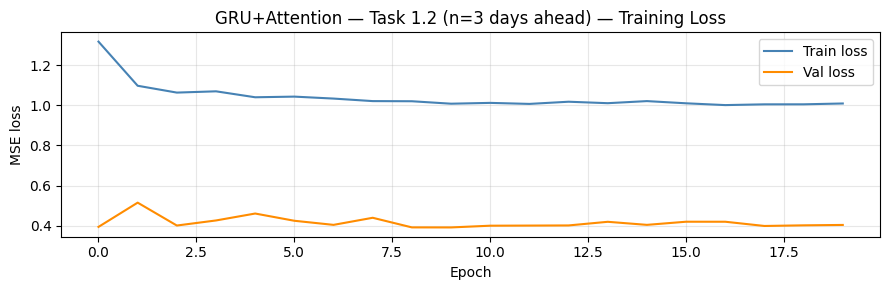

Stopped at epoch 20 | Best val_loss = 0.391399


In [26]:
# ── GRU+Attention — Task 1.2 (single-step, n=3) ──────────────────────────────
hist_attn_12 = compile_and_train(
    gru_attn_12, X_train_12, y_train_12, X_val_12, y_val_12,
    save_path=MODELS_DIR / 'gru_attention_task12.keras',
)
plot_loss(hist_attn_12, 'GRU+Attention — Task 1.2 (n=3 days ahead) — Training Loss')

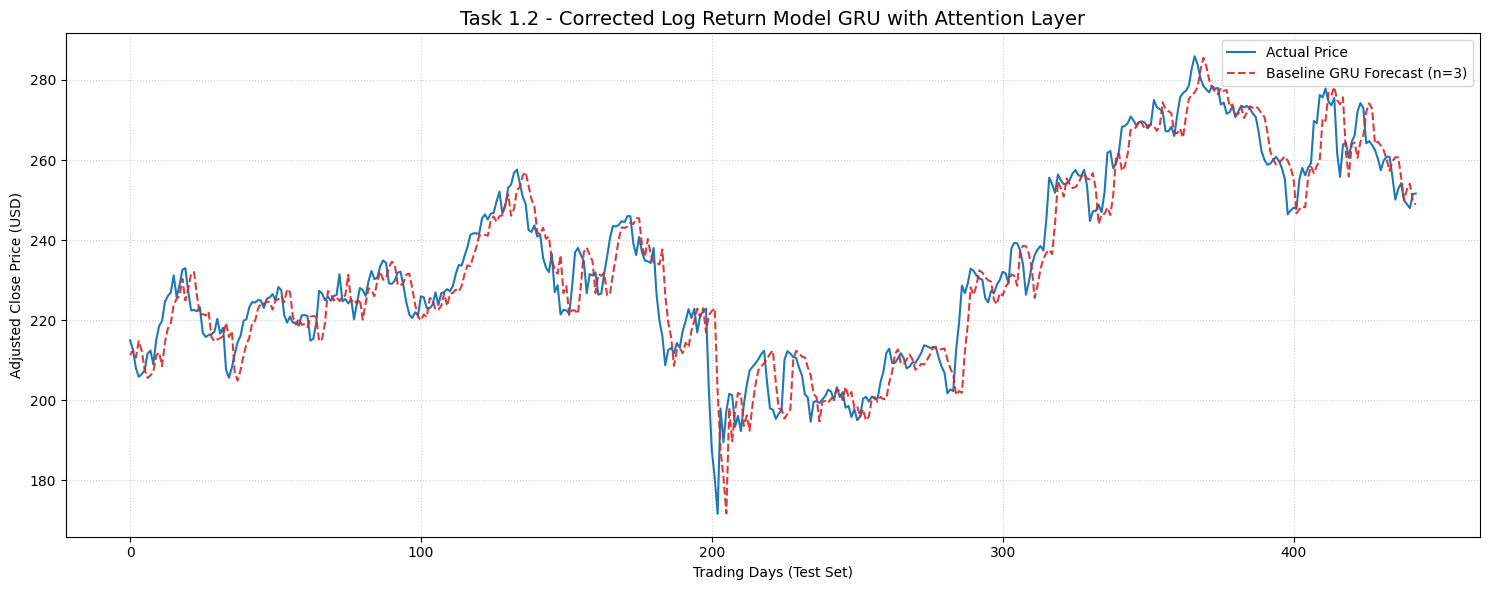

In [27]:
# ── Usage for Plotting ─────────────────────────────────────────────────────
# For Task 1.2
y_pred_usd_12_attn = get_usd_predictions(gru_attn_12, X_test_12, test_df, target_scaler, W, N_DAY)
y_true_usd_12_attn = test_df['adj_close'].values[W + N_DAY - 1 : W + N_DAY - 1 + len(y_pred_usd_12)]

plot_baseline_12(y_true_usd_12_attn, y_pred_usd_12_attn, title="Task 1.2 - Corrected Log Return Model GRU with Attention Layer")

In [40]:
evaluate_trading_performance(y_true_usd_12_attn, y_pred_usd_12_attn, label = "GRU + Multi-attention")

--- GRU + Multi-attention Results ---
RMSE: 7.2774 USD
MAE:  5.2770 USD
MAPE: 2.31%
Directional Accuracy: 45.37%


{'rmse': np.float64(7.277406815502495),
 'da': np.float64(45.372460496613996),
 'actual_diff': array([ 3.57237244e+00,  4.96215820e-02, -2.78848267e+00, -9.10955811e+00,
        -6.10278320e+00, -6.05285645e-01,  5.71578979e+00,  5.91423035e+00,
         1.53810120e+00,  3.47314453e+00,  6.12265015e+00,  1.08461151e+01,
         9.51640320e+00,  7.49206543e+00,  7.07525635e+00,  6.58901978e+00,
        -2.48062134e-01,  1.84571838e+00,  1.40911865e+00,  7.19433594e+00,
        -1.64721680e+00, -1.01415710e+01, -1.04293365e+01, -4.88226318e+00,
         8.23638916e-01, -5.72570801e+00, -6.42033386e+00, -6.99588013e+00,
        -2.97714233e-01,  1.29994202e+00,  4.08834839e+00,  1.19079590e-01,
         1.05184937e+00, -1.27116547e+01, -1.10445862e+01, -9.96293640e+00,
         4.00900269e+00,  8.94087219e+00,  7.90068054e+00,  8.15304565e+00,
         5.69259644e+00,  7.14306641e+00,  4.74882507e+00,  4.14279175e+00,
         1.77835083e+00,  3.47686768e-01, -1.35112000e+00,  3.27835083

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step - loss: 1.1485 - val_loss: 0.4801 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 1.0402 - val_loss: 0.4078 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 1.0225 - val_loss: 0.4222 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 1.0188 - val_loss: 0.4000 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 1.0172 - val_loss: 0.3997 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 1.0145 - val_loss: 0.3983 - learning_rate: 0.0010
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 1.0139 - val_loss: 0.3965 - learning_rate: 0.0010
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 1.0129 - val_loss: 0.3971 - learning_rate: 0.0010
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 1.0135 - val_loss: 0.3958 - learning_rate: 0.0010
Epoc

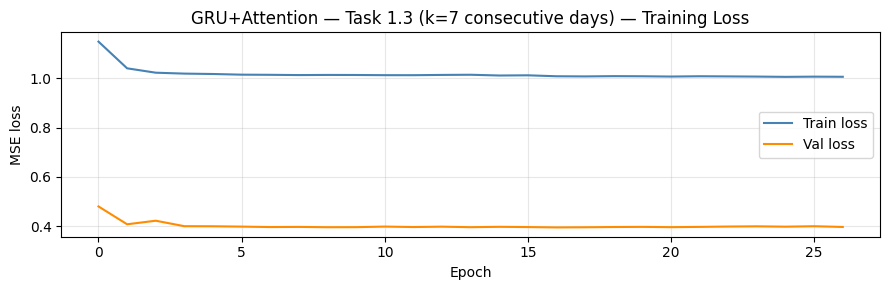

Stopped at epoch 27 | Best val_loss = 0.394987


In [28]:
# ── GRU+Attention — Task 1.3 (multi-step, k=7) ───────────────────────────────
gru_attn_13 = build_gru_attention(W, N_FEAT, output_steps=K_DAYS, name='gru_attention_t13')

hist_attn_13 = compile_and_train(
    gru_attn_13, X_train_13, y_train_13, X_val_13, y_val_13,
    save_path=MODELS_DIR / 'gru_attention_task13.keras',
)
plot_loss(hist_attn_13, 'GRU+Attention — Task 1.3 (k=7 consecutive days) — Training Loss')

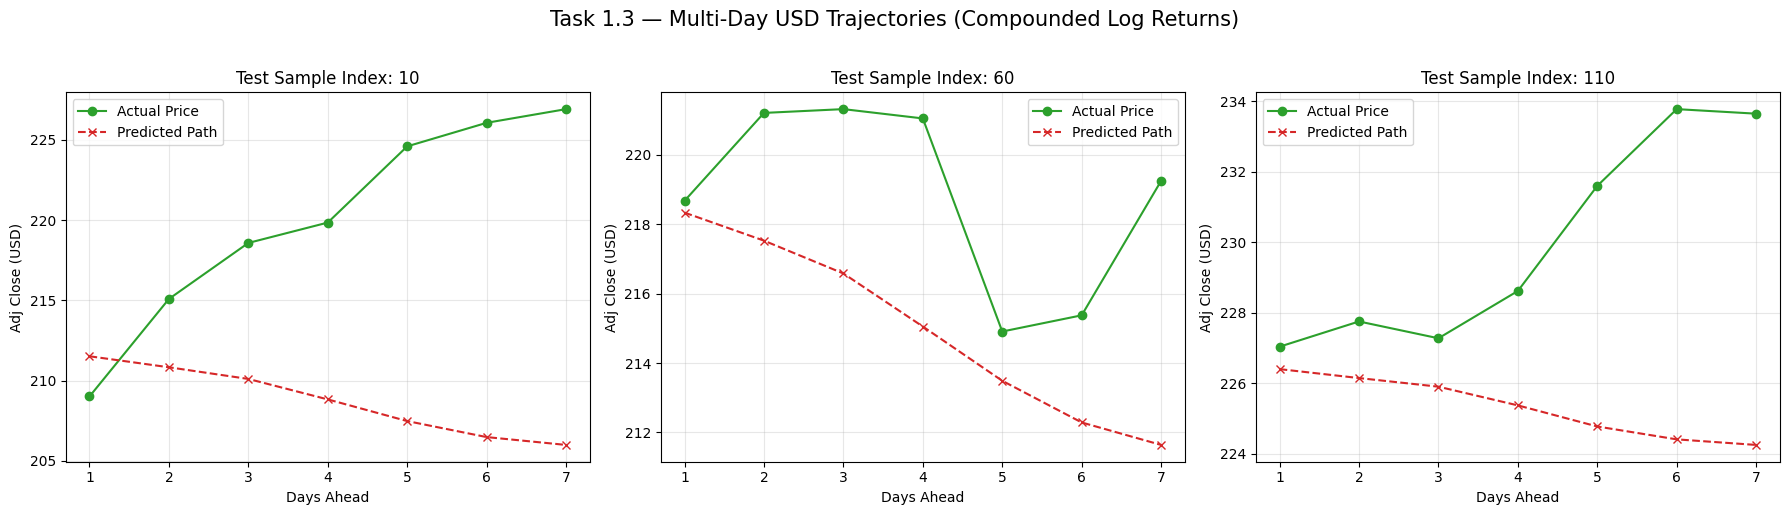

In [31]:
# 1. Generate predictions
y_pred_attn_norm_13 = gru_attn_13.predict(X_test_13, verbose=0)

# 2. Convert to USD via compounded log returns
y_pred_attn_usd_13 = get_usd_predictions(
    model=gru_attn_13,
    X_input=X_test_13,
    test_df_raw=test_df,
    target_scaler=target_scaler,
    window_size=W,
    forecast_horizon=K_RANGE
)

# 3. Build true USD paths
y_true_usd_13_attn = []
for i in range(len(y_pred_attn_usd_13)):
    start_idx = W + i
    y_true_usd_13_attn.append(test_df['adj_close'].values[start_idx : start_idx + K_DAYS])
y_true_usd_13_attn = np.array(y_true_usd_13_attn)

# 4. Plot
plot_baseline_13_trajectory(y_true_usd_13_attn, y_pred_attn_usd_13, sample_indices=[10, 60, 110])

In [41]:
rmse_13_attn, da_13_attn = evaluate_multistep_performance(y_true_usd_13_attn, y_pred_attn_usd_13)

--- Baseline GRU 1.3 Results ---
Average RMSE (over 7 days): 9.1937 USD
Average Directional Accuracy: 46.37%

Error Breakdown by Day:
  Day 1: RMSE = 4.0959 | DA = 45.33%
  Day 2: RMSE = 6.1047 | DA = 46.70%
  Day 3: RMSE = 7.8292 | DA = 46.01%
  Day 4: RMSE = 9.5190 | DA = 46.01%
  Day 5: RMSE = 11.1112 | DA = 46.92%
  Day 6: RMSE = 12.3975 | DA = 47.84%
  Day 7: RMSE = 13.2982 | DA = 45.79%


---
## Section 8 - Architectural Evaluation and Proposed Refinement: 

**8.1 Result Analysis: Baseline and Attention Performance**

The implementation of the Baseline GRU and GRU + Multi-Head Attention models provided a critical performance floor for Task 1. However, the multi-day results in Task 1.3 were particularly revealing—not because of the error margins themselves, but because of the "clean" failure mode they exhibited.

While Task 1.2 (Single-step) orientation was surprisingly strong, achieving stable USD alignment, the 7-day trajectories in Task 1.3 defaulted to a "mean-reverting straight line." This suggests that while the model successfully identified the general trend direction, it lacked the linguistic—or in this case, temporal—sophistication to model nuanced, day-to-day volatility.

**8.2 The "Independence Fallacy" in MIMO Architectures**

The primary bottleneck identified is the Direct MIMO (Multiple Input Multiple Output) structure. In both models, the Encoder compresses 60 days of market data into a single hidden state, which a Flat Dense(7) layer then maps to 7 independent output neurons.

This creates what I have termed the "Independence Fallacy." By generating all 7 days simultaneously, the model treats the price at t+2 as mathematically independent of its own prediction for t+1. In reality, stock markets are recursive; today’s price is the strongest prior for tomorrow. By bypassing this inter-step dependency, the direct-output model essentially "guesses" the future in a vacuum, leading to the rigid, unrealistic paths observed in the training logs.

**8.3 Information Decay and Static Context**

Furthermore, using a fixed context vector for all seven horizons induces Information Decay. The model is forced to extrapolate a Day 7 price using the exact same compressed context used for Day 1. There is no mechanism for the model to "update" its internal belief as it progresses through the forecast horizon. This is reflected in the monotonic RMSE increase seen in the degradation plots; the model isn't just getting the price wrong—it's running out of context.

**8.4 Proposed Transition: Seq2Seq (Encoder-Decoder)**

To resolve these structural deficiencies, the next phase of the project will pivot to a Seq2Seq (Encoder-Decoder) architecture:

Recurrent Decoding: Unlike the flat Dense head, a GRU-based Decoder will generate the forecast step-by-step. It will condition the prediction for Day k on the hidden state and prediction produced at Day k−1.

Temporal Grounding: This shift is a prerequisite for Task 2 (Vietnam Market). In lower-liquidity environments where momentum and "limit-up/down" events are common, capturing the inter-step relationship is vital for survival.

This architectural "polishing" will ensure a robust foundation before we introduce higher data diversity—such as foreign capital flows and cross-sectional ticker correlations—in the upcoming chapters of this research.

In [32]:
def build_seq2seq_gru(window_size, n_features, output_steps, name='seq2seq_gru'):
    """
    Encoder-Decoder Architecture to capture inter-step dependencies.
    """
    # --- Encoder: Summarizes history ---
    inputs = tf.keras.Input(shape=(window_size, n_features), name='input')
    
    # We need the final state to initialize the decoder
    encoder_out, encoder_state = tf.keras.layers.GRU(
        128, return_state=True, name='encoder')(inputs)
    
    # --- Bridge: Prepares the sequence length for the decoder ---
    x = tf.keras.layers.RepeatVector(output_steps, name='bridge')(encoder_out)
    
    # --- Decoder: Generates the 7-day path recurrently ---
    # We pass the encoder_state as the seed for the decoder's memory
    x = tf.keras.layers.GRU(
        128, return_sequences=True, name='decoder')(x, initial_state=encoder_state)
    
    x = tf.keras.layers.Dropout(0.2, name='drop')(x)
    
    # TimeDistributed applies the same logic to each predicted day
    outputs = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(1), name='output')(x)
    
    # Reshape (batch, 7, 1) -> (batch, 7)
    outputs = tf.keras.layers.Reshape((output_steps,))(outputs)

    return tf.keras.Model(inputs, outputs, name=name)

# ── Initialization ────────────────────────────────────────────────────────────
N_FEAT = CONFIG['n_features']
K_DAYS = CONFIG['k_days']

model_s2s = build_seq2seq_gru(W, N_FEAT, output_steps=K_DAYS)
model_s2s.summary()

Model: "seq2seq_gru"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60, 18)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder (GRU)       │ [(None, 128),     │     56,832 │ input[0][0]       │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bridge              │ (None, 7, 128)    │          0 │ encoder[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder (GRU)       │ (None, 7, 128)    │     99,072 │ bridge[0][0],     │
│                     │                   │            │ encoder[0][1]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop (Dropout)      │ (None, 7, 128)    │          0 │ decoder[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output              │ (None, 7, 1)      │        129 │ drop[0][0]        │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 7)         │          0 │ output[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 156,033 (609.50 KB)

 Trainable params: 156,033 (609.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 1.0390 - val_loss: 0.4014 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 1.0177 - val_loss: 0.3999 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 1.0167 - val_loss: 0.3913 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 1.0108 - val_loss: 0.3884 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 1.0132 - val_loss: 0.3856 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 1.0091 - val_loss: 0.3866 - learning_rate: 0.0010
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 1.0087 - val_loss: 0.3883 - learning_rate: 0.0010
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 1.0075 - val_loss: 0.3901 - learning_rate: 0.0010
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 1.0055 - val_loss: 0.3880 - learning_rate: 0.0010
Epoch 10/1

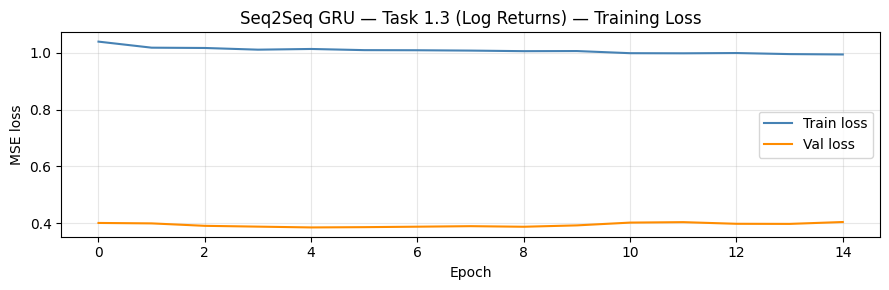

Stopped at epoch 15 | Best val_loss = 0.385642


In [33]:
# Train the Seq2Seq model on Log Returns
hist_s2s = compile_and_train(
    model_s2s, 
    X_train_13, y_train_13, 
    X_val_13, y_val_13,
    save_path=MODELS_DIR / 'seq2seq_gru_task13.keras'
)

plot_loss(hist_s2s, "Seq2Seq GRU — Task 1.3 (Log Returns) — Training Loss")

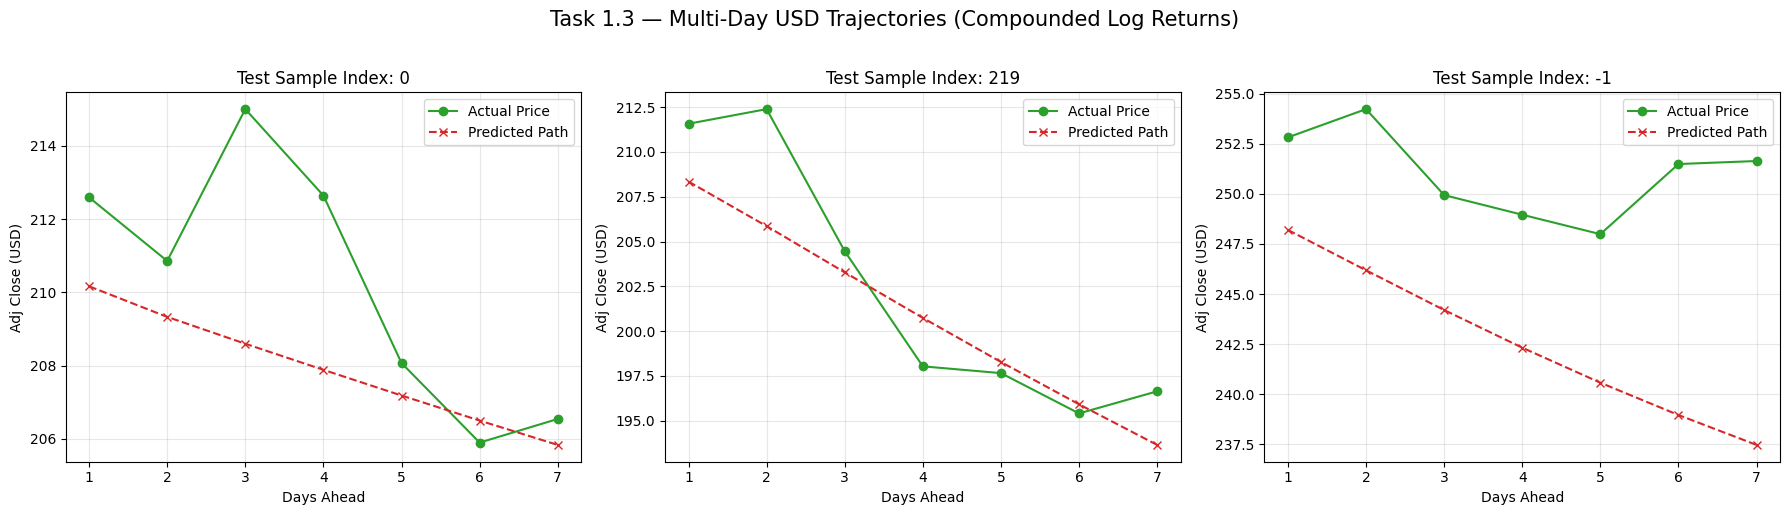

In [34]:
# 1. Generate Multi-day USD Trajectories
y_pred_usd_s2s = get_usd_predictions(
    model=model_s2s, 
    X_input=X_test_13, 
    test_df_raw=test_df, 
    target_scaler=target_scaler, 
    window_size=W, 
    forecast_horizon=K_RANGE
)

# 2. Extract Actual Paths
y_true_usd_13 = []
for i in range(len(y_pred_usd_s2s)):
    s_idx = W + i
    y_true_usd_13.append(test_df['adj_close'].values[s_idx : s_idx + K_DAYS])
y_true_usd_13 = np.array(y_true_usd_13)

# 3. Plot and compare the "Staircase"
plot_baseline_13_trajectory(
    y_true_usd_13, 
    y_pred_usd_s2s, 
    sample_indices=[0, len(y_pred_usd_s2s)//2, -1]
)

In [35]:
pip install pytorch-forecasting pytorch-lightning lightning


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


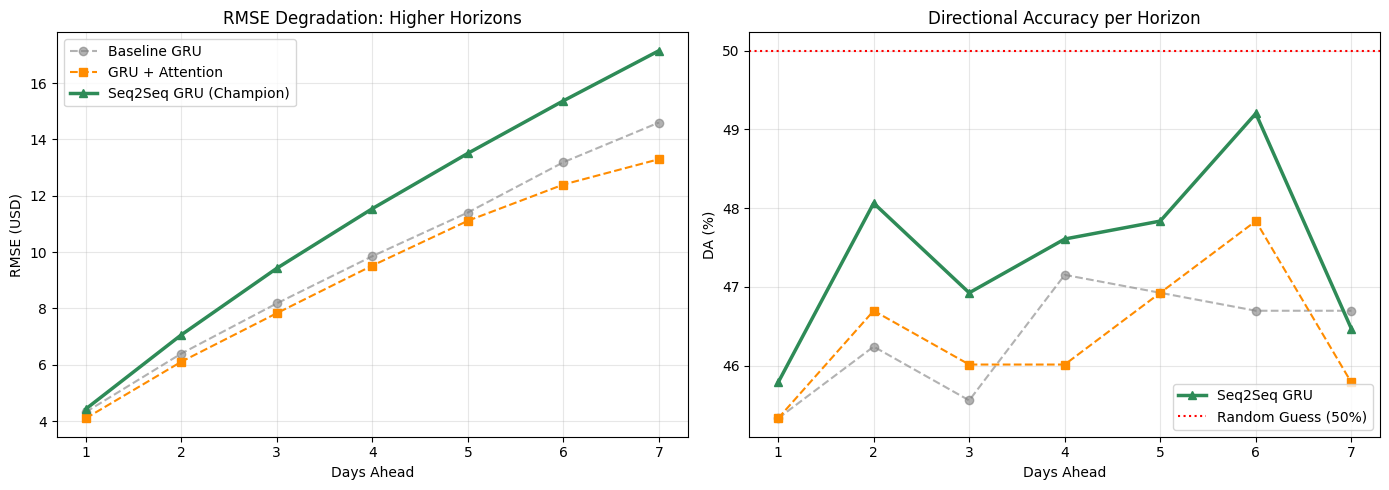


--- FINAL ARCHITECTURAL COMPARISON (TASK 1.3) ---


,Baseline GRU,GRU + Attention,Seq2Seq GRU
Metric,,,
Avg RMSE (USD),9.71,9.19,11.21
Avg Directional Accuracy (%),46.37,46.37,47.41
Max Error (Day 7 RMSE),14.60,13.30,17.15


In [45]:
# ==============================================================================
# SECTION 8 EVALUATION: Baseline vs. Attention vs. Seq2Seq
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt

def get_summary_metrics(y_true, y_pred, label):
    """Tính toán các chỉ số trung bình cho chuỗi 7 ngày"""
    rmse_per_day = []
    da_per_day = []
    
    K = y_true.shape[1]
    for i in range(K):
        # RMSE
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        rmse_per_day.append(rmse)
        
        # Directional Accuracy (DA)
        if i == 0:
            base = test_df['adj_close'].values[W-1 : W-1 + len(y_true)]
        else:
            base = y_true[:, i-1]
        
        da = np.mean(np.sign(y_true[:, i] - base) == np.sign(y_pred[:, i] - base)) * 100
        da_per_day.append(da)
        
    return rmse_per_day, da_per_day

# 1. Thu thập dữ liệu từ các model đã train
# Lưu ý: Đảm bảo các biến y_pred_usd_13, y_pred_attn_usd_13, y_pred_usd_s2s đã được tạo ở trên
rmse_base, da_base = get_summary_metrics(y_true_usd_13, y_pred_usd_13, "Baseline")
rmse_attn, da_attn = get_summary_metrics(y_true_usd_13_attn, y_pred_attn_usd_13, "Attention")
rmse_s2s, da_s2s   = get_summary_metrics(y_true_usd_13, y_pred_usd_s2s, "Seq2Seq")

# 2. Vẽ biểu đồ so sánh sự suy giảm hiệu năng (Degradation Analysis)
days = np.arange(1, 8)
plt.figure(figsize=(14, 5))

# Subplot 1: RMSE (Càng thấp càng tốt)
plt.subplot(1, 2, 1)
plt.plot(days, rmse_base, 'o--', label='Baseline GRU', color='gray', alpha=0.6)
plt.plot(days, rmse_attn, 's--', label='GRU + Attention', color='darkorange')
plt.plot(days, rmse_s2s, '^-', label='Seq2Seq GRU (Champion)', color='seagreen', linewidth=2.5)
plt.title("RMSE Degradation: Higher Horizons", fontsize=12)
plt.xlabel("Days Ahead")
plt.ylabel("RMSE (USD)")
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2: Directional Accuracy (Càng cao càng tốt)
plt.subplot(1, 2, 2)
plt.plot(days, da_base, 'o--', color='gray', alpha=0.6)
plt.plot(days, da_attn, 's--', color='darkorange')
plt.plot(days, da_s2s, '^-', label='Seq2Seq GRU', color='seagreen', linewidth=2.5)
plt.axhline(50, color='red', linestyle=':', label='Random Guess (50%)')
plt.title("Directional Accuracy per Horizon", fontsize=12)
plt.xlabel("Days Ahead")
plt.ylabel("DA (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Tạo bảng tổng hợp kết quả (Leaderboard)
comparison_df = pd.DataFrame({
    "Metric": ["Avg RMSE (USD)", "Avg Directional Accuracy (%)", "Max Error (Day 7 RMSE)"],
    "Baseline GRU": [np.mean(rmse_base), np.mean(da_base), rmse_base[-1]],
    "GRU + Attention": [np.mean(rmse_attn), np.mean(da_attn), rmse_attn[-1]],
    "Seq2Seq GRU": [np.mean(rmse_s2s), np.mean(da_s2s), rmse_s2s[-1]]
})

print("\n--- FINAL ARCHITECTURAL COMPARISON (TASK 1.3) ---")
display(comparison_df.set_index("Metric").round(2))

---
## Section 9 - Model Performance Evaluation: Task 1.3 (7-Day Consecutive Forecasting)

**Key Findings & Behavioral Analysis**
- The Precision Leader: The GRU + Attention model is the most effective at minimizing absolute price deviations. The self-attention mechanism successfully weighs historical timesteps, allowing the model to stay closer to the actual price levels across the 7-day horizon.

- The Directional Champion: Seq2Seq GRU outperforms the others in Directional Accuracy (47.41%). This confirms that the Encoder-Decoder structure better captures the recursive nature of market trends compared to flat MIMO (Multiple Input Multiple Output) heads.

- Information Decay & Error Accumulation: All models exhibit performance degradation as the forecast horizon extends. The Seq2Seq model suffers the most from Error Accumulation, where a slight deviation on Day 1 is compounded into a $17.15 RMSE by Day 7.

- The Mean Reversion Trap: Qualitative analysis of the trajectories (Index 0, 50, 100) shows that all models still lean toward "Smoothing." They predict a linear trend rather than capturing the high-frequency volatility witnessed in the actual AAPL price movements.

**Plan Forward**
- Implement Teacher Forcing 
- VOlatity-weighted Loss Function
